In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import math
import cmath

In [2]:
#@title constants

H = 8e-3 # 8 mmm
W = 64 * 0.15e-3 # 64 layers of 0.15 mm = 9.6 mm

rho = 1000 #kg.m^-3 . I hope that the Fraunhofer formula uses the same equation
v = 1500 # speed of sound
a = 0.52e-4 # 0.52 dB/(MHz.cm) = 0.52e-4 dB/(Hz.m)
f = 7.5e6 # frequency
wlength = v/f # wave length
k = 2*np.pi/wlength
mu = a/10 * math.log(10) *f # m^-1 geschikt voor e-macht.


In [3]:
#@title function signalfactor
def signalfactor(source, destination):
# bereken afstand
# bereken signaalsterkte e^(-mu*r)*r^-2
# bereken fase e^ikr
  r=np.linalg.norm(source-destination)
  return math.exp(-mu*r)/(r*r)*np.array([math.cos(k*r), math.sin(k*r) ])


In [4]:
#@title function sumOverSources
def sumOverSources(H, L, destination):

  sum = np.zeros(2)
  for i in range(H.size):
    for j in range(L.size):
      sum += signalfactor(np.array([H[i],L[j],0]),destination)
  return sum/(H.size*L.size)

In [5]:
#@title function Fraunhofer_absOnAxis
def Fraunhofer_absOnAxis(z, k, f, rho, WH =1 ):
    result= rho*v/(2*z) * WH
    return result

0.0002
31415.92653589793


Text(0, 0.5, 'wave pressure')

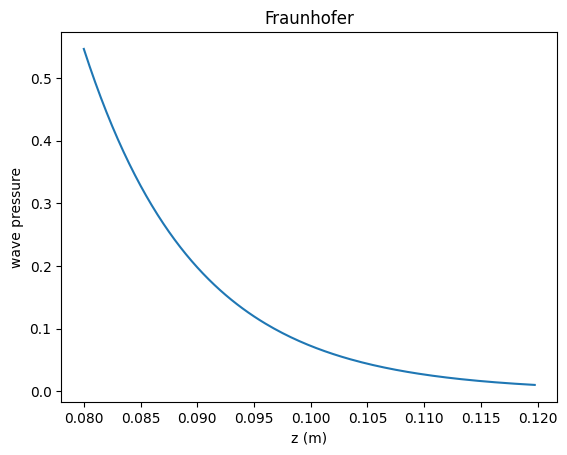

In [6]:
#@title plot abs(Fraunhofer)
print(wlength)
print(k)
zF = np.arange(0.08,0.12,5/4*wlength) # z is in m, range is 12 cm
IFraunhofer = np.zeros(zF.size)
for i in range(zF.size):
  IFraunhofer[i]= math.exp(-mu*zF[i]) * Fraunhofer_absOnAxis(zF[i], k, f, rho, W*H)
plt.plot(zF,abs(IFraunhofer))
plt.title("Fraunhofer")
plt.xlabel('z (m)')
plt.ylabel('wave pressure')


0.0002
0.008
0.0096
245


Text(0, 0.5, 'wave pressure')

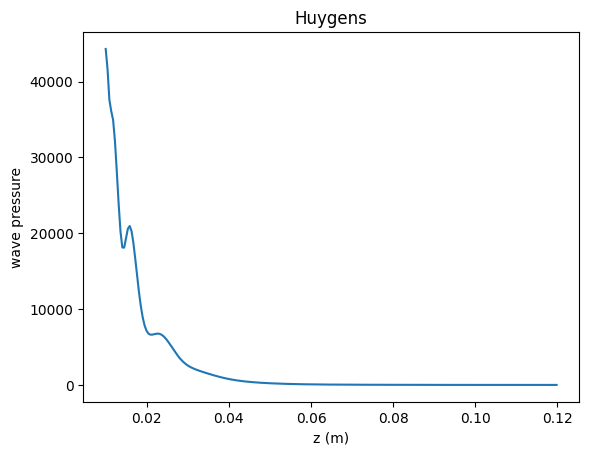

In [7]:
print(wlength)
print(H)
print(W)
z = np.arange(0.01,0.12,9/4*wlength) # z is in m, range is 12 cm
print(z.size)
x = np.arange(wlength/2,H/2,wlength/4)
y = np.arange(wlength/2,W/2,wlength/4)
I=np.zeros([z.size,2])
for i in range(z.size):
  destination = np.array([0,0,z[i]])
  I[i,:]= 4*np.linalg.norm(sumOverSources(x,y, destination))*rho*v*W*H
plt.plot(z,I[:,1])
plt.title("Huygens")
plt.xlabel('z (m)')
plt.ylabel('wave pressure')
#print(sumOverSources(x,y, np.array([0,0,0.08])))

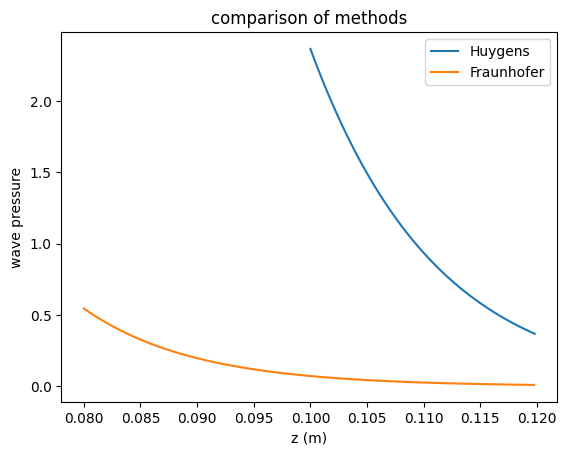

In [8]:
plt.plot(z[200:],I[200:,1], label = "Huygens")
plt.plot(zF,IFraunhofer, label = "Fraunhofer")
plt.title("comparison of methods")
plt.xlabel('z (m)')
plt.ylabel('wave pressure')
plt.legend()